In [1]:
from notebook_env import *
from tqdm import tqdm

## Read and parse AlpacaEval dataset

In [2]:
output_length_threshold = 250

models = [
    'gpt-3.5-turbo-1106',
    'gpt-4o-mini-2024-07-18',
    'gpt-4o-2024-05-13',
]

costs = {  # $1/1M tokens
    'gpt-3.5-turbo-1106': 1.5,
    'gpt-4o-mini-2024-07-18': 0.6,
    'gpt-4o-2024-05-13': 10,
}
inspection_cost = 300/1e3  # $300/1K examples

reward_per_win = 2

In [3]:
files = [f'data/alpacaeval/alpacaeval-{m}.json' for m in models]

df0 = (
    pd.concat([
        pd.read_json(f)
        for f in files
    ])
    .assign(
        # https://github.com/tatsu-lab/alpaca_eval/blob/main/src/alpaca_eval/analyze.py#L536
        p1=lambda df: 2-df['preference'],
        win1=lambda df: df['p1']>0.5,
        win2=lambda df: ~df['win1'],
        longer1=lambda df: df['output_1'].str.len()>df['output_2'].str.len(),
        longer2=lambda df: ~df['longer1'],
        len1=lambda df: df['output_1'].str.len(),
        len2=lambda df: df['output_2'].str.len(),
        longoutput=lambda df: df['len2']>=output_length_threshold,
    )  
)
df0.head()

,instruction,output_1,generator_1,dataset,output_2,generator_2,annotator,preference,price_per_example,time_per_example,raw_completion,p1,win1,win2,longer1,longer2,len1,len2,longoutput
0,What are the names of some famous actors that ...,Several famous actors started their careers on...,gpt4_1106_preview,helpful_base,Some famous actors who started their careers o...,gpt-3.5-turbo-1106,weighted_alpaca_eval_gpt4_turbo,1.000001,0.00835,0.179811,"{'finish_reason': 'length', 'index': 0, 'logpr...",0.999999,True,False,True,False,2104,213,False
1,How did US states get their names?,The names of U.S. states are derived from a va...,gpt4_1106_preview,helpful_base,The names of U.S. states have diverse origins....,gpt-3.5-turbo-1106,weighted_alpaca_eval_gpt4_turbo,1.000000,0.01152,0.179811,"{'finish_reason': 'length', 'index': 0, 'logpr...",1.000000,True,False,True,False,3394,544,True
2,"Hi, my sister and her girlfriends want me to p...",Kickball is a fun and simple game that is simi...,gpt4_1106_preview,helpful_base,Of course! Kickball is a fun and simple game t...,gpt-3.5-turbo-1106,weighted_alpaca_eval_gpt4_turbo,1.000006,0.01205,0.179811,"{'finish_reason': 'length', 'index': 0, 'logpr...",0.999994,True,False,True,False,3025,942,True
3,What is some cool music from the 1920s?,"The 1920s, often referred to as the ""Roaring T...",gpt4_1106_preview,helpful_base,"In the 1920s, the jazz age was in full swing, ...",gpt-3.5-turbo-1106,weighted_alpaca_eval_gpt4_turbo,1.000138,0.01057,0.179811,"{'finish_reason': 'length', 'index': 0, 'logpr...",0.999862,True,False,True,False,2908,379,True
4,How do I wrap a present neatly?,Wrapping a present neatly can be quite straigh...,gpt4_1106_preview,helpful_base,"To wrap a present neatly, follow these steps:\...",gpt-3.5-turbo-1106,weighted_alpaca_eval_gpt4_turbo,1.000039,0.00951,0.179811,"{'finish_reason': 'length', 'index': 0, 'logpr...",0.999961,True,False,True,False,2341,521,True


In [4]:
# Number of prompts per generator
df0.groupby('generator_2')['len2'].agg(['count','mean'])

,count,mean
generator_2,,
gpt-3.5-turbo-1106,805,796.675776
gpt-4o-2024-05-13,805,1873.452174
gpt-4o-mini-2024-07-18,805,1861.248447


## Contract design evaluation

In [5]:
def build_df_norm(df): 
    " Compute aggregate signal and outcome distributions from raw data "
    return (
        df
        .groupby(['generator_2','longoutput','win2'])
        ['win2']
        .count()
        .unstack()
        .unstack()
        .apply(lambda row: row/row.sum(), axis=1)
        .fillna(0)
        .loc[models]
    )

def build_design_problem(df, df_norm):
    " Construct signal and outcome distribution matrices "
    # Signal
    q0_df=(
        df_norm
        .stack(future_stack=True)
        .sum(axis=1)
        .unstack()
        .loc[models]
        .sort_index(axis=1)
    )
    q0 = q0_df.to_numpy()
    l = q0.shape[1]
    # Outcome
    q=[
        (
            df_norm
            .stack(future_stack=True)
            .apply(lambda row: row/row.sum(), axis=1)
            .swaplevel()
            .loc[k]
            .loc[models]
            .to_numpy()
        )
        for k in q0_df.columns
    ]
    # Alternative signal
    q0_costly_df = (
        df_norm
        .stack(future_stack=True)
        .stack(future_stack=True)
        .swaplevel(1,2)
        .unstack()
        .sum(axis=1)
        .unstack()
    )
    q0_costly = q0_costly_df.to_numpy()
    return {
        'q0':q0,
        'q0_df': q0_df,
        'q':q,
        'q0_costly': q0_costly,
    }

def evaluate(df, *, inspection_cost=inspection_cost, reward_per_win=reward_per_win):
    " Evaluate adaptive contracts and non-adaptive baselines "
    # Action costs
    c = (
        (np.array([costs[m] for m in models])/1e6)  # $1/1M tokens
        * (df.groupby('generator_2')['len2'].mean().loc[models].to_numpy()/4)  # ~4 characters/token, 
    )
    df_norm = build_df_norm(df)
    design_problem = build_design_problem(df, df_norm)
    design_problem['c'] = c

    results = []
    for target in range(len(models)):
        # Enumerate inspection policies
        for p in itertools.product([0,1],repeat=2):
            try:
                t,obj = contract_optimization.DiscreteInspectionContractOptimizer.solve_for_fixed_p(
                    q0=design_problem['q0'],
                    q=design_problem['q'],
                    c=c,
                    d=np.array([1,1])*inspection_cost,
                    p=p,
                    target=target,
                )
            except (TypeError, RuntimeError):
                t,obj = (None, None)    
            results.append({
                'target': models[target],
                'target_ind': target,
                'p': p,
                't': t,
                'pay': obj,
            })
        # Use only costly signal
        try:
            t,obj = contract_optimization.MinPayOptimizer.solve(
                F=design_problem['q0_costly'],
                c=c,
                target=target,
            )
            obj += inspection_cost
        except (ValueError, TypeError, RuntimeError):
            t,obj = (None, None)
        results.append({
            'target': models[target],
            'target_ind': target,
            'p': 'only_inspect',
            't': t,
            'pay': obj,
        })

    success_rates = df.groupby('generator_2')['win2'].mean().loc[models]
    c_argmin = c.argmin()
    results.append({
        'target': models[c_argmin],
        'target_ind': c_argmin,
        'p': 'naive',
        't': None,
        'pay': c.max(),
    })
    
    results_df = (
        pd.DataFrame(results)
        .join(
            success_rates,
            on='target',
        )
        .assign(
            reward=lambda df: df['win2']*reward_per_win,
            utility=lambda df: df['reward']-df['pay'],
        )   
    )
    return results_df, df_norm, design_problem

results_df, df_norm, design_problem = evaluate(df0)
results_df.tail()

,target,target_ind,p,t,pay,win2,reward,utility
11,gpt-4o-2024-05-13,2,"(0, 1)","[6.312597658089218e-10, -3.583355747457774e-11...",0.291952,0.541615,1.083230,0.791278
12,gpt-4o-2024-05-13,2,"(1, 0)","[-3.0157372931006905e-11, 0.4655990590971783, ...",0.080949,0.541615,1.083230,1.002280
13,gpt-4o-2024-05-13,2,"(1, 1)","[6.037279404472584e-10, 0.37283236425992416, -...",0.321814,0.541615,1.083230,0.761416
14,gpt-4o-2024-05-13,2,only_inspect,None,NaN,0.541615,1.083230,NaN
15,gpt-4o-mini-2024-07-18,1,naive,None,0.004684,0.439752,0.879503,0.874819


In [6]:
matrix_to_latex = lambda a, *, fmt=lambda x: f'{x:.2f}': (
    '\\begin{pmatrix}\n'
    + '\\\\ \n'.join(' & '.join(fmt(x) for x in row) for row in np.atleast_2d(a))
    + '\n\\end{pmatrix}'
)
print('\\bq^0 =',matrix_to_latex(design_problem['q0']))
print('\\bq^1 =',matrix_to_latex(design_problem['q'][0]))
print('\\bq^2 =',matrix_to_latex(design_problem['q'][1]))


\bq^0 = \begin{pmatrix}
0.21 & 0.79\\ 
0.10 & 0.90\\ 
0.11 & 0.89
\end{pmatrix}
\bq^1 = \begin{pmatrix}
0.78 & 0.22\\ 
0.61 & 0.39\\ 
0.54 & 0.46
\end{pmatrix}
\bq^2 = \begin{pmatrix}
0.95 & 0.05\\ 
0.56 & 0.44\\ 
0.45 & 0.55
\end{pmatrix}


In [7]:
print('\\bc = ', matrix_to_latex(design_problem['c'], fmt=lambda x: f'{x:.5f}'))

\bc =  \begin{pmatrix}
0.00030 & 0.00028 & 0.00468
\end{pmatrix}


In [8]:
print('\\bd = ', matrix_to_latex(np.atleast_2d(np.array([1,1])*inspection_cost), fmt=lambda x: f'{x:.1f}'))

\bd =  \begin{pmatrix}
0.3 & 0.3
\end{pmatrix}


In [9]:
print(
    'R_i = ',
    matrix_to_latex(np.atleast_2d((reward_per_win*df0.groupby('generator_2')['win2'].mean().loc[models]).to_numpy())),
)

R_i =  \begin{pmatrix}
0.17 & 0.88 & 1.08
\end{pmatrix}


<Axes: xlabel='target'>

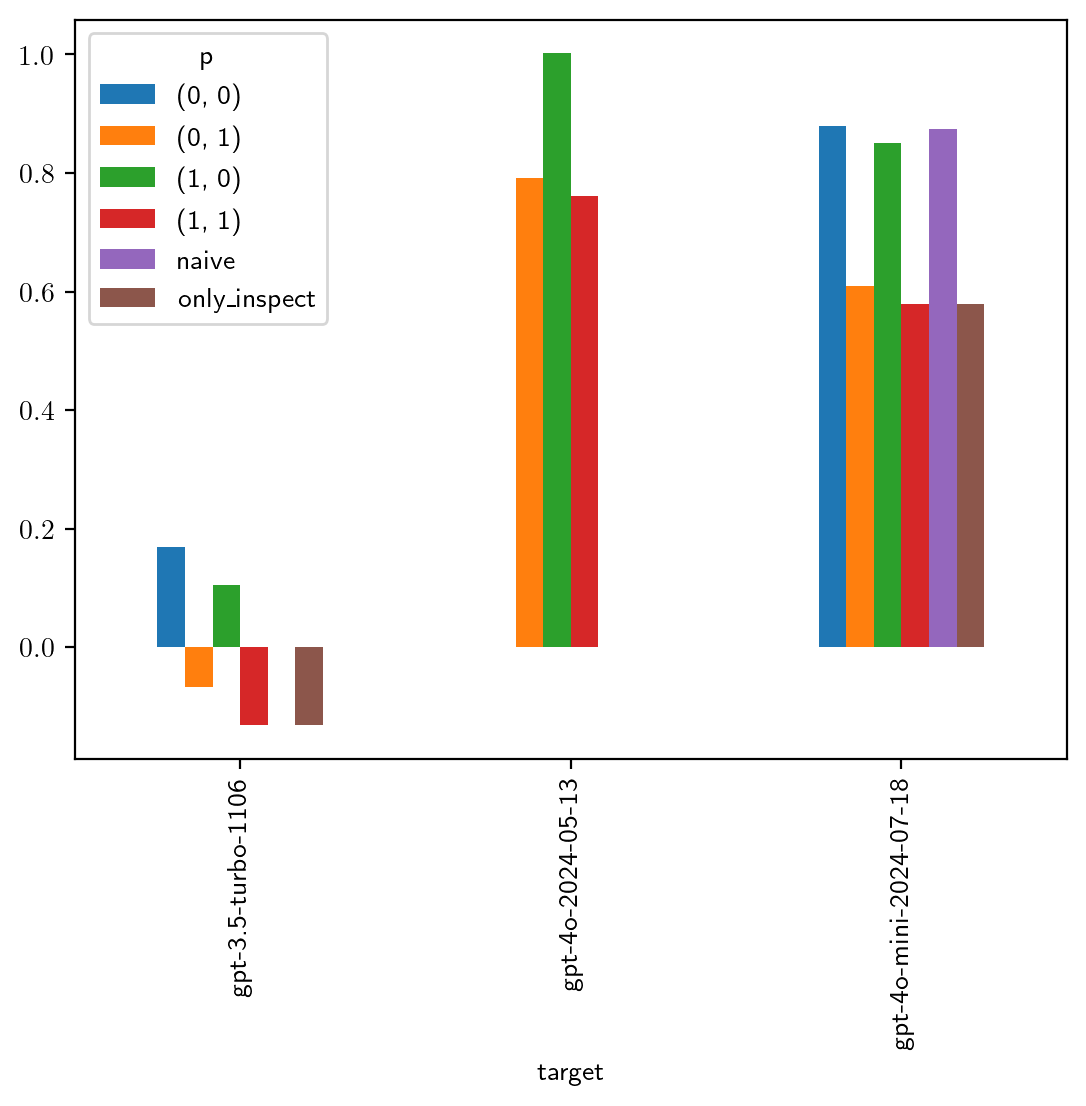

In [10]:
(
    results_df
    .set_index(['target','p'])
    ['utility']
    .unstack()
    .plot.bar()
)

np.float64(0.1395985179372865)

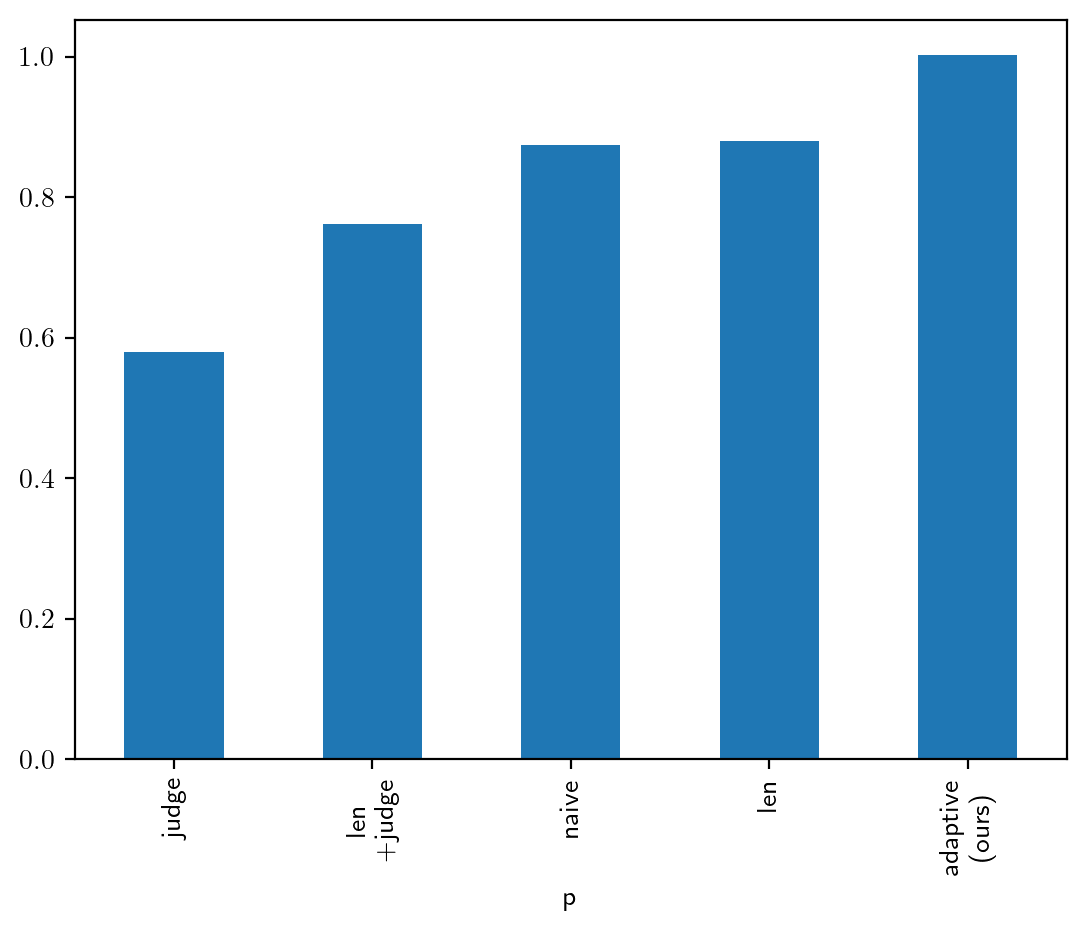

In [11]:
build_compare_df = lambda results_df: (
    results_df
    .groupby('p')
    ['utility']
    .max()
)
compare_df = (
    build_compare_df(results_df)
    .drop((0,1))
    .sort_values()
    .rename({
        (1,1): 'len\n+judge',
        (0,0): 'len',
        'only_inspect': 'judge',
        (1,0): 'adaptive\n(ours)',
        # 'naive': 'constant',
    })
)
compare_df.plot.bar()
compare_df.iloc[-1]/compare_df.iloc[-2]-1

## Results

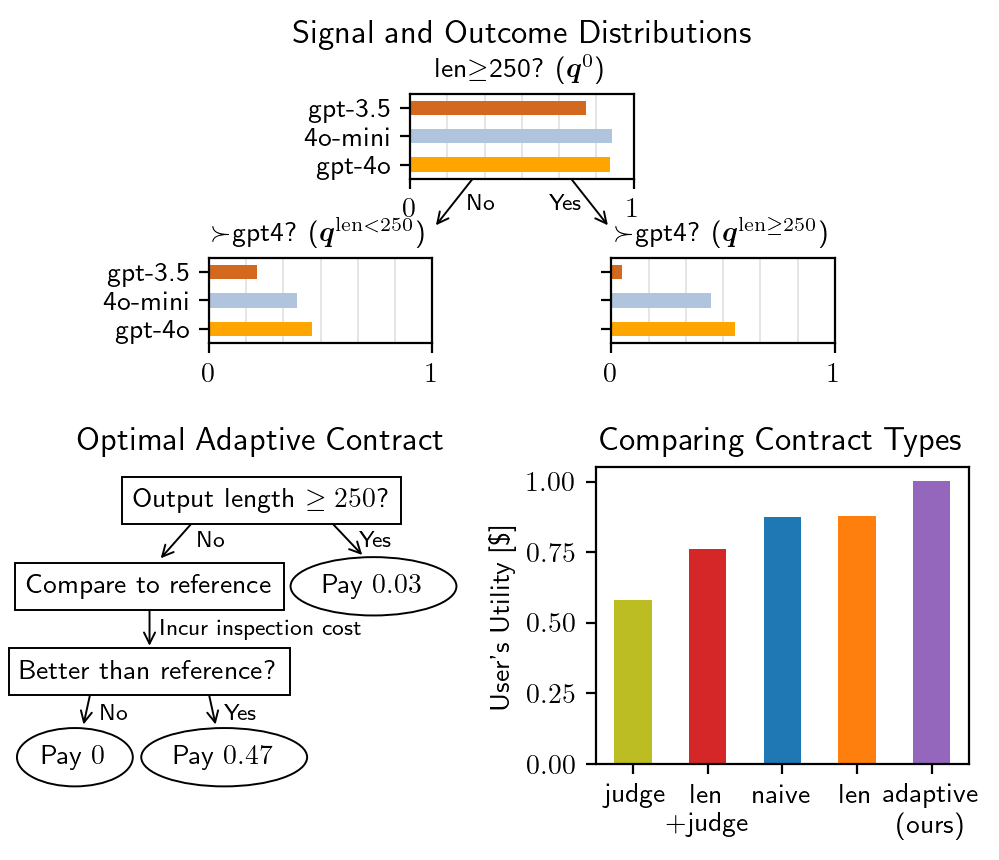

In [12]:
fig,axs=plt.subplot_mosaic(
    mosaic=[[0,0],[1,2]],
    constrained_layout={
        # 'w_pad':1e-1,
        'h_pad':1e-1,
        'w_pad':5e-2,
    },
    height_ratios=[1,1.05],
    figsize=(4.9,4.3),
)

# fig,axs = plt.subplots(
#     1,3,
#     figsize=(10,2.7),
#     constrained_layout={
#         'h_pad':1e-1,
#         'w_pad':5e-2,
#     },
# )

ax=axs[0]
arrowprops=dict(arrowstyle='->',lw=0.7)
arrow = lambda xy1, xy2: ax.annotate('', xytext=xy1, xy=xy2, arrowprops=arrowprops, zorder=-1)
arrow((0.45,0.6), (0.4,0.4))
ax.text(0.44,0.47,'No',fontsize=8)
arrow((0.55,0.6), (0.6,0.4))
ax.text(0.53,0.47,'Yes',fontsize=8)

names = {
    'gpt-3.5-turbo-1106': 'gpt-3.5',
    'gpt-4o-mini-2024-07-18': '4o-mini',
    'gpt4': 'gpt-4',
    'gpt-4o-2024-05-13': 'gpt-4o',
}
colors = {
    'gpt-3.5-turbo-1106': 'chocolate',
    'gpt-4o-mini-2024-07-18': 'lightsteelblue',
    'gpt4': 'magenta',
    'gpt-4o-2024-05-13': 'orange',
}
ax.set(
    title='Signal and Outcome Distributions',
)
ins_h = 0.22
ins_w = 0.25
ins_x0 = 0.15
ins1 = ax.inset_axes(
    [0.5-ins_w/2,0.8-ins_h,ins_w,0.3],
)
plot_barh = lambda q,ax: (
    q
    .iloc[:,1]
    .loc[models[::-1]]
    .rename(names)
    .plot.barh(
        ax=ax,
        xlim=(0,1),
        ylabel='',
        color=[colors[m] for m in models][::-1],
    )
)
design_problem['q0_df'].pipe(plot_barh, ax=ins1)
ins1.set(
    xticks=[0,1],
)
ins1.set_title(
    'len$\\geq$%d? ($\\bq^0$)' % output_length_threshold,
    fontsize=10,
)

ins2 = ax.inset_axes(
    [ins_x0,0,ins_w,0.3],
)
df_norm.swaplevel(axis=1)[False].apply(lambda row: row/row.sum(),axis=1).pipe(plot_barh, ax=ins2)
ins2.set(
    xticks=[0,1],
)
ins2.set_title(
    '$\\succ$gpt4? ($\\bq^{\\mathrm{len} < %d}$)' % output_length_threshold,
    fontsize=10,
)

ins3 = ax.inset_axes(
    [1-ins_w-ins_x0,0,ins_w,0.3],
)
df_norm.swaplevel(axis=1)[True].apply(lambda row: row/row.sum(),axis=1).pipe(plot_barh, ax=ins3)
ins3.set(
    ylabel=None,
    yticks=ins2.get_yticks(),
    xticks=ins2.get_xticks(),
    yticklabels=[],
)
ins3.set_title(
    '$\\succ$gpt4? ($\\bq^{\\mathrm{len} \\geq %d}$)' % output_length_threshold,
    fontsize=10,
)
for ins in [ins1,ins2,ins3]:
    for x in np.linspace(0,1,7)[1:-1]:
        ins.axvline(x, c='lightgray', lw=0.7, alpha=0.6, zorder=-1)
ax.axis('off')


ax=axs[1]
ax.set(
    title='Optimal Adaptive Contract',
    ylim=(0.15,1.02),
)
ax.axis('off')
bbox = {'fc':'w','lw':0.7}
best_contract = results_df.loc[results_df['utility'].idxmax()]
assert best_contract.p == (1,0)
t = np.maximum(best_contract['t'],0)
ax.text(0.5,0.9,s='Output length $\\geq %d$?' % output_length_threshold,ha='center',bbox=bbox)
ax.text(0.8,0.65,s='Pay $%.2f$' % t[2],ha='center',bbox={'boxstyle':'ellipse'}|bbox)
ax.text(0.2,0.65,s='Compare to reference',ha='center',bbox=bbox)
ax.text(0.2,0.4,s='Better than reference?',ha='center',bbox=bbox)
ax.text(0.0,0.15,s='Pay $%g$' % t[0],ha='center',bbox={'boxstyle':'ellipse'}|bbox)
ax.text(0.4,0.15,s='Pay $%.2f$' % t[1],ha='center',bbox={'boxstyle':'ellipse'}|bbox)
arrow = lambda xy1, xy2: ax.annotate('', xytext=xy1, xy=xy2, arrowprops=arrowprops, zorder=-1)
arrow((0.35,0.9),(0.22,0.74))
arrow((0.65,0.9),(0.78,0.75))
arrow((0.2,0.65),(0.2,0.48))
arrow((0.35,0.4),(0.38,0.25))
arrow((0.05,0.4),(0.02,0.25))
ax.text(0.76,0.785,'Yes',fontsize=8)
ax.text(0.33,0.785,'No',fontsize=8)
ax.text(0.4,0.28,'Yes',fontsize=8)
ax.text(0.07,0.28,'No',fontsize=8)
ax.text(0.23,0.525,'Incur inspection cost',fontsize=8)

ax=axs[2]
ax.set(
    title='Comparing Contract Types',
)
colors = {
    'judge': 'tab:olive',
    'len+judge': 'tab:red',
    'naive': 'tab:blue',
    'len': 'tab:orange',
    'adaptive': 'tab:purple',
}
barp = compare_df.plot.bar(
    ax=ax,
    rot=0,
    ylabel='User\'s Utility [\\$]',
    # xlabel='Contract Type',
    color=[colors[t.replace('\n','').replace('(ours)','')] for t in compare_df.index],
)
ax.set(
    xlabel=None,
)
fig.savefig(
    './output/alpacaeval.pdf',
    bbox_inches='tight',
)

## Sensitivity analysis

In [13]:
pnames = {
    (1,1): 'len+judge',
    (0,0): 'len',
    'only_inspect': 'judge',
    (1,0): 'adaptive10',
    (0,1): 'adaptive01',
}
adaptives = ['adaptive10','adaptive01']

In [14]:
bootstrap_n = 100
bootstrap_rng = np.random.default_rng(12345)

bootstrap_compare_df = pd.concat([
    build_compare_df(evaluate(
        df=pd.concat([
            df0.query('instruction==@inst')
            for inst in
            bootstrap_rng.choice(df0['instruction'].unique(),size=df0['instruction'].nunique())
        ]),
        reward_per_win=2,
    )[0]).to_frame().assign(rep=rep)
    for rep in tqdm(range(bootstrap_n))
]).rename(pnames)

100%|██████████| 100/100 [02:18<00:00,  1.38s/it]


<Axes: xlabel='p'>

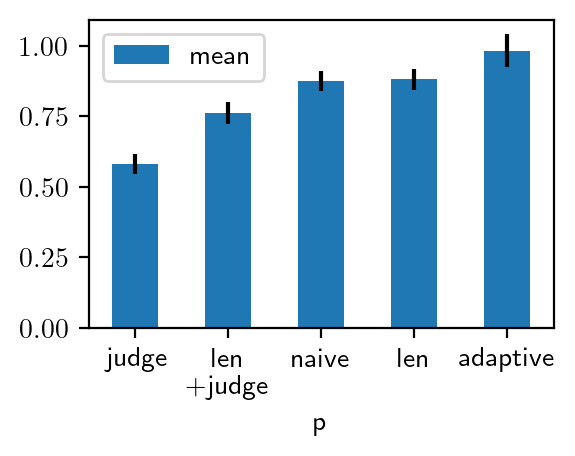

In [15]:
(
    bootstrap_compare_df
    .reset_index()
    .set_index(['rep','p'])
    .unstack()
    ['utility']
    .assign(adaptive=lambda df: df.apply(lambda row: row.max(), axis=1))
    .agg(['mean','std'])
    .transpose()
    .sort_values('mean')
    .drop(adaptives)
    .pipe(lambda df: df.rename({i:i.replace('+','\n+') for i in df.index}))
    .plot.bar(y='mean',yerr='std',figsize=(3,2),rot=0)
)

<Axes: xlabel='p'>

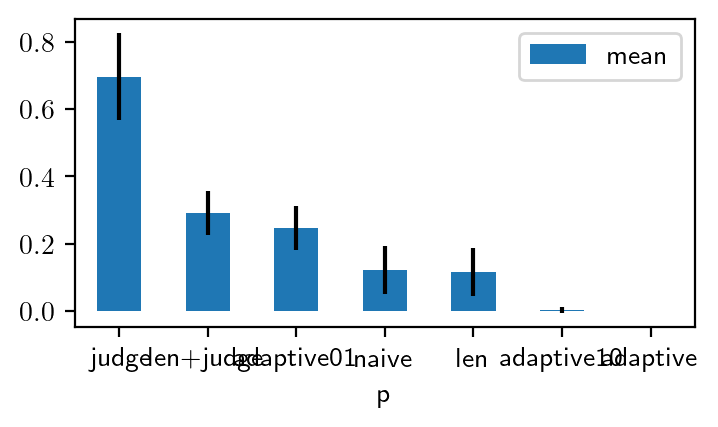

In [16]:
(
    bootstrap_compare_df
    .reset_index()
    .set_index(['rep','p'])
    .unstack()
    ['utility']
    .assign(adaptive=lambda df: df.apply(lambda row: row.max(), axis=1))
    .apply(lambda row: row.max()/row-1, axis=1)
    .agg([
        'mean',
        'std',
    ])
    .transpose()
    .sort_values('mean', ascending=False)
    # .drop(adaptives)
    # .pipe(lambda df: df.rename({i:i.replace('+','\n+') for i in df.index}))
    .plot.bar(y='mean',yerr='std',figsize=(4,2),rot=0)
)

In [17]:
reward_df = pd.concat([
    build_compare_df(evaluate(
        df=df0,
        reward_per_win=r,
    )[0]).to_frame().assign(r=r)
    for r in tqdm(np.linspace(0.5,7,50))
]).rename(pnames)
reward_df.head()

100%|██████████| 50/50 [00:01<00:00, 26.64it/s]


,utility,r
p,,
len,0.219876,0.5
adaptive01,-0.021145,0.5
adaptive10,0.190435,0.5
len+judge,-0.051007,0.5
naive,0.215192,0.5


In [18]:
inspection_cost_df = pd.concat([
    build_compare_df(evaluate(
        df=df0,
        inspection_cost=d,
    )[0]).to_frame().assign(d=d)
    for d in tqdm(np.linspace(0.0,1.6,50))
]).rename(pnames)
inspection_cost_df.head()

100%|██████████| 50/50 [00:02<00:00, 24.46it/s]


,utility,d
p,,
len,0.879503,0.0
adaptive01,1.059601,0.0
adaptive10,1.033957,0.0
len+judge,1.061416,0.0
naive,0.874819,0.0


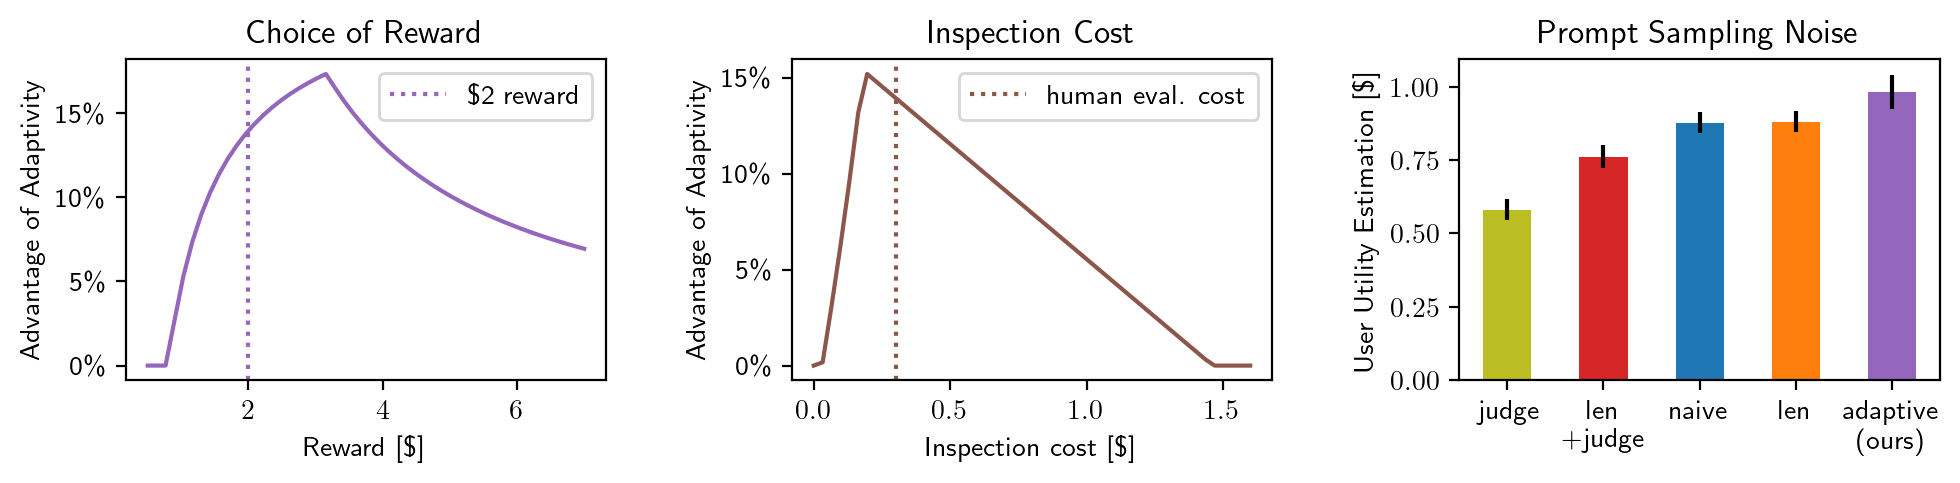

In [19]:
fig,axs = plt.subplots(1,3,figsize=(10,2.3),
   constrained_layout={
        'w_pad':2e-1,
    },
)
ax=axs[0]
c='tab:purple'
(
    reward_df
    .reset_index()
    .set_index(['r','p'])
    .unstack()
    ['utility']
    .apply(lambda row: row.max()/row.drop(adaptives).max()-1, axis=1)
    .plot.line(
        ax=ax,
        xlabel='Reward [\$]',
        ylabel='Advantage of Adaptivity',
        title='Choice of Reward',
        color=c,
    )
)
# ax.axhline(0)
ax.axvline(reward_per_win,linestyle=':',color=c,label=f'\${reward_per_win} reward')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0,decimals=0))
ax.legend()

ax=axs[1]
c='tab:brown'
(
    inspection_cost_df
    .reset_index()
    .set_index(['d','p'])
    .unstack()
    ['utility']
    .apply(lambda row: row.max()/row.drop(adaptives).max()-1, axis=1)
    .plot.line(
        ax=ax,
        xlabel='Inspection cost [\$]',
        ylabel='Advantage of Adaptivity',
        title='Inspection Cost',
        color=c,
    )
)
ax.axvline(
    inspection_cost,
    linestyle=':',
    color=c,
    # label='human comparison',
    label='human eval. cost',
)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0,decimals=0))
ax.legend()

ax=axs[2]
(
    bootstrap_compare_df
    .reset_index()
    .set_index(['rep','p'])
    .unstack()
    ['utility']
    .assign(adaptive=lambda df: df.apply(lambda row: row.max(), axis=1))
    .agg(['mean','std'])
    .transpose()
    .sort_values('mean')
    .drop(adaptives)
    .pipe(lambda df: df.rename({i:i.replace('+','\n+') for i in df.index}))
    .pipe(lambda df: df.rename({'adaptive':'adaptive\n(ours)'}))
    .pipe(lambda df: df.plot.bar(
        ax=ax,
        y='mean',
        yerr='std',
        rot=0,
        color=[colors[t.replace('\n','').replace('(ours)','')] for t in df.index],
        legend=None,
        title='Prompt Sampling Noise',
        xlabel='',
        ylabel='User Utility Estimation [\\$]',
    ))
)

fig.savefig('./output/alpacaeval_sensitivity.pdf')

## Bootstrap confidence intervals

In [20]:
ci_alpha = 0.95

def binomial_ci(s,alpha=ci_alpha): 
    n = s.count()
    p_hat = s.sum()/n
    z = scipy.stats.norm.isf((1-alpha)/2)
    return pd.Series({
        'est': p_hat,
        'err': (z/np.sqrt(n))*np.sqrt(p_hat*(1-p_hat)),
    })

(
    bootstrap_compare_df
    .reset_index()
    .set_index(['rep','p'])
    .unstack()
    ['utility']
    .assign(
        delta=lambda df: df.apply(lambda row: row.max()-row.drop(adaptives).max(), axis=1),
        delta_rel=lambda df: df.apply(lambda row: row.max()/row.drop(adaptives).max()-1, axis=1),
        adaptive=lambda df: df.apply(lambda row: row.max(), axis=1),
    )
    ['delta']
    .map(lambda x: x>0)
    .agg(binomial_ci)
    .pipe(lambda s: print(f'Strictly positive gain in {s.iloc[0]:.2%} +- {s.iloc[1]:.1%} of repetitions'))
)

Strictly positive gain in 90.00% +- 5.9% of repetitions


In [21]:
(
    bootstrap_compare_df
    .reset_index()
    .set_index(['rep','p'])
    .unstack()
    ['utility']
    .assign(
        delta=lambda df: df.apply(lambda row: row.max()-row.drop(adaptives).max(), axis=1),
        delta_rel=lambda df: df.apply(lambda row: row.max()/row.drop(adaptives).max()-1, axis=1),
        adaptive=lambda df: df.apply(lambda row: row.max(), axis=1),
    )
    ['delta']
    .where(lambda x: x>0)
    .dropna()
    .agg([
        'mean',
        lambda s: s.quantile((1-ci_alpha)/2),
        lambda s: s.quantile(1-(1-ci_alpha)/2),
    ])
    .pipe(lambda s: print(f'Gain is in [{s.iloc[1]:.1%}, {s.iloc[2]:.1%}] when strictly positive'))
)

Gain is in [1.5%, 21.2%] when strictly positive
